The code is available in the github repo in /hw_05 here I only included some parts only for reference to answer homework questions, in my notes you can see more information. In case you are interested in the process please visit the workshop made by agrigorev here: [Workshop](https://github.com/DataTalksClub/machine-learning-zoomcamp/tree/master/05-deployment/workshop)

Question 1 \
Install uv \
What's the version of uv you installed? \
Use --version to find out

In [1]:
#make sure you use .venv kernel
uv_version = !uv --version
print(f"Installed uv version is: {uv_version.s}")

Installed uv version is: uv 0.9.5


Question 2 \
Use uv to install Scikit-Learn version 1.6.1 \
What's the first hash for Scikit-Learn you get in the lock file? \
Include the entire string starting with sha256:, don't include quotes

First hash of scikit-learn 1.6.1 in uv.lock file:

sha256:b4fc2525eca2c69a59260f583c56a7557c6ccdf8deafdba6e060f94c1c59738e

Question 3 \
Let's use the model! \
Write a script for loading the pipeline with pickle \
Score this record: \
{"lead_source": "paid_ads", "number_of_courses_viewed": 2, "annual_income": 79276.0}

Get the pipeline.bin and add it to your uv folder: [pipeline](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2025/05-deployment/pipeline_v1.bin)

Load pipeline with Pickle and 

In [2]:
import pickle

In [3]:
# pipeline is composed of DictVectorizer and LogisticRegression model
pipe_name = "pipeline_v1.bin"
with open(pipe_name, "rb") as pipe_in:
    pipeline = pickle.load(pipe_in)
pipeline

Pipeline(steps=[('dictvectorizer', DictVectorizer()),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

In [4]:
data = {
    "lead_source": "paid_ads",
    "number_of_courses_viewed": 2,
    "annual_income": 79276.0
}

In [5]:
proba_score = pipeline.predict_proba(data)[0, 1]

In [6]:
print(f"Probability scored: {proba_score}")

Probability scored: 0.5336072702798061


Question 4 \
Now let's serve this model as a web service

Install FastAPI \
Write FastAPI code for serving the model \
Now score this client using requests:

client = {
    
    "lead_source": "organic_search",
    "number_of_courses_viewed": 4,
    "annual_income": 80304.0
}

FastAPI code to serve model (only for reference purposes)

In [7]:
if None: #just preventing code execution
    import pickle
    import uvicorn

    from fastapi import FastAPI
    from typing import Dict, Any

    #load model
    with open("pipeline_v1.bin", "rb") as pipe_in:
        pipeline = pickle.load(pipe_in)

    #predict single observation
    def predict_single(observation):
        score = pipeline.predict_proba(observation)[0, 1]
        return float(score)

    predict_churn_telco = FastAPI(title="predict_churn_telco")

    @predict_churn_telco.post("/predict_churn_telco")
    def predict(observation: Dict[str, Any]):
        score = predict_single(observation)
        return {"score": score, "is_churn": bool(score >= 0.5)}

    def main():
        uvicorn.run("main:predict_churn_telco", host="0.0.0.0", port=4444)

    if __name__ == "__main__":
        main()

Code to score a client (only for reference purposes)

In [8]:
if None: #just preventing code execution
    import requests

    url = ("http://localhost:4444/predict_churn_telco")

    observation = {
        "lead_source": "organic_search",
        "number_of_courses_viewed": 4,
        "annual_income": 80304.0
    }

    response = requests.post(url, json=observation)
    result = response.json()

    print(result)
    print("About to Churn" if result["is_churn"] else "No Churn")

Result

{'score': 0.5340417283801275, 'is_churn': True}

About to Churn

Question 5 \
Download the base image [agrigorev/zoomcamp-model:2025](https://hub.docker.com/r/agrigorev/zoomcamp-model)\
You can easily make it by using docker pull command.

So what's the size of this base image?

![Screenshot from 2025-10-26 10-34-07.png](<attachment:Screenshot from 2025-10-26 10-34-07.png>)
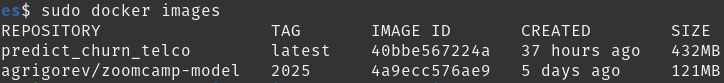

Thse size of the downloaded agrigorev/zoomcamp-model is displayed as 121MB

Dockerfile\
Now create your own Dockerfile based on the image we prepared.

It should start like that:

FROM agrigorev/zoomcamp-model:2025\
-- add your stuff here\
Now complete it:

Install all the dependencies from pyproject.toml\
Copy your FastAPI script\
Run it with uvicorn\
After that, you can build your docker image.

In [9]:
#Dockerfile contents previous to Q6
if None:
    """
    FROM agrigorev/zoomcamp-model:2025

    COPY --from=ghcr.io/astral-sh/uv:latest /uv /uvx /bin/
    WORKDIR /code

    ENV PATH="/code/.venv/bin:$PATH"

    COPY "pyproject.toml" "uv.lock" ".python-version" ./
    RUN uv sync --locked

    COPY "main.py" ./

    EXPOSE 4444

    ENTRYPOINT ["uvicorn", "main:predict_churn_telco", "--host", "0.0.0.0", "--port", "4444"]
    """

In [10]:
#build image using previous Dockerfile
if None:
    """
    sudo docker build -t agrigorev/zoomcamp-model .
    """

Question 6\
Let's run your docker container!

After running it, score this client once again:

url = "YOUR_URL"\
client = {\
    "lead_source": "organic_search",\
    "number_of_courses_viewed": 4,\
    "annual_income": 80304.0\
}\
requests.post(url, json=client).json()\
What's the probability that this lead will convert?

In [11]:
#Run docker image
if None:
    """
        sudo docker run -it --rm -p 4444:4444 agrigorev/zoomcamp-model
    """

Sending request with client data

![Screenshot from 2025-10-26 12-50-47.png](<attachment:Screenshot from 2025-10-26 12-50-47.png>)
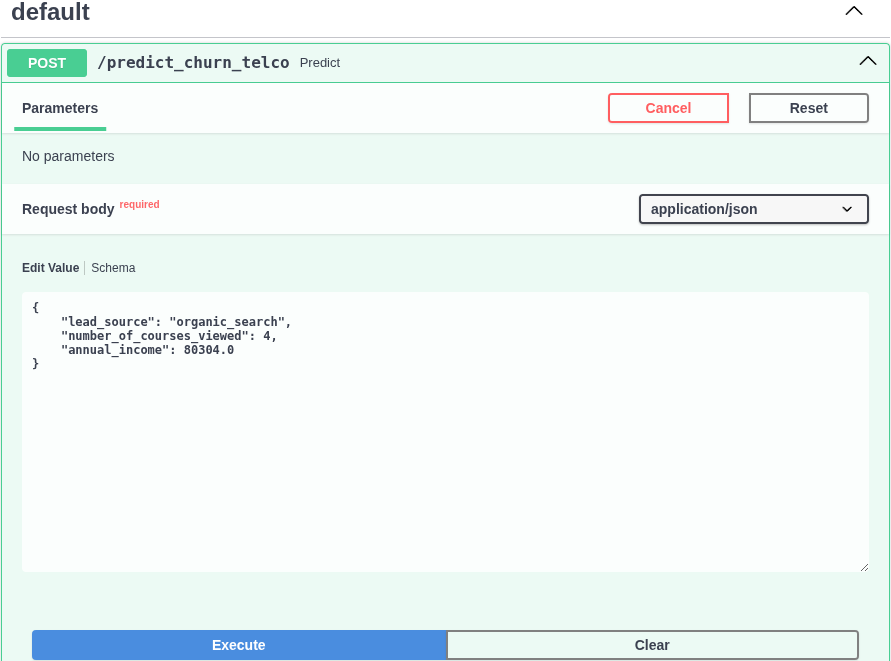

Reviewing response

![Screenshot from 2025-10-26 12-52-14.png](<attachment:Screenshot from 2025-10-26 12-52-14.png>)
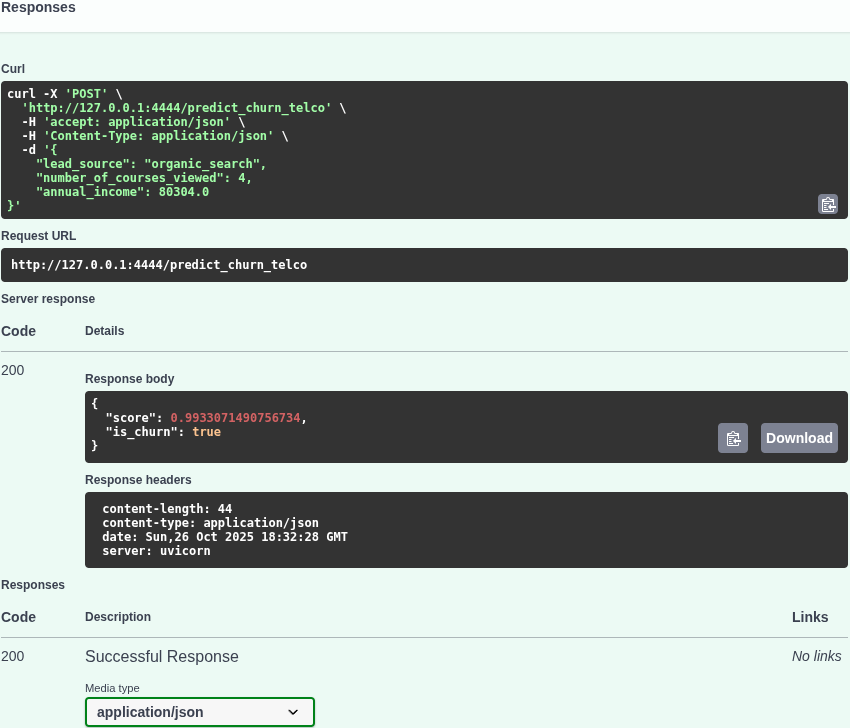